
# 01 - Exploratory Analysis

## Evaluación 2 - Análisis exploratorio, visualizaciones y enfoque del modelado

Este notebook concentra el análisis exploratorio inicial solicitado para la Evaluación 2.  
Se trabaja con el dataset final generado por Kedro, por lo que los datos ya pasaron por las etapas de ingesta, limpieza, transformación y validación.

El notebook está dividido en tres bloques principales:

1. **EDA general:** revisión inicial del dataset final.
2. **EDA logístico:** análisis visual de patrones operacionales.
3. **Enfoque del modelado:** definición y justificación de las variables objetivo para Machine Learning.



## Índice del notebook

Puedes navegar por las secciones desde el panel lateral de Jupyter o usando los encabezados principales:

- [1. Configuración inicial](#1-configuración-inicial)
- [2. Carga del dataset final](#2-carga-del-dataset-final)
- [3. EDA general del dataset](#3-eda-general-del-dataset)
- [4. Análisis visual logístico](#4-análisis-visual-logístico)
- [5. Enfoque del problema predictivo](#5-enfoque-del-problema-predictivo)
- [6. Conclusiones del análisis exploratorio](#6-conclusiones-del-análisis-exploratorio)



# 1. Configuración inicial

En esta sección se cargan las librerías necesarias y se conecta el notebook con el proyecto Kedro.


In [1]:

%load_ext kedro.ipython

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)


The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython



# 2. Carga del dataset final

El dataset utilizado corresponde a la salida final del flujo Kedro:

`data/05_model_input/dataset_modelo.csv`

Este archivo se utiliza porque ya contiene los datos limpios, integrados, validados y con variables derivadas creadas durante el pipeline de transformación.


In [2]:

df = catalog.load("dataset_modelo")

df.head()


[05/07/26 16:41:09] INFO     Loading data from dataset_modelo (CSVDataset)...                  ]8;id=6603222;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=6603223;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia
0,1.00,2023-01-01,39.00,46.00,"12,675.80",28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.30,16.70,urbana,"1,950.00",ouuc-52,camión,"10,000.00",20.50,"2,022.00",en mantención,"17,043.00",0.00,0.00,sin incidencia,0.00,4.00,55.05,1.27,1.39,1
1,2.00,NaN,3.00,27.00,13.60,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.60,18.40,urbana,"2,447.00",fgkf-38,van,"1,000.00",22.10,"2,010.00",operativo,"88,004.00",0.00,0.00,sin incidencia,0.00,7.00,36.93,0.01,1.13,1
2,3.00,2023-01-02,73.00,18.00,"2,536.00",50.55,refrigerada,entregado,NaN,maipú,san antonio,468.40,5.20,ruta nacional,"11,768.00",agdn-22,furgón,"20,000.00",38.90,"2,023.00",en mantención,"243,705.00",0.00,0.00,sin incidencia,0.00,7.00,90.08,0.13,1.30,1
3,4.00,2023-01-03,49.00,45.00,466.00,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,"1,642.40",18.90,ruta nacional,"7,202.00",ialh-88,van,"1,000.00",25.30,"2,015.00",operativo,"224,573.50",1.00,"1,747,372.00",desvío de ruta,1.00,4.00,86.90,0.47,0.55,1
4,5.00,NaN,17.00,36.00,"4,928.90",0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,"1,556.60",17.90,urbana,"3,799.00",glfy-29,camioneta,"5,000.00",49.10,"2,023.00",operativo,"138,259.00",0.00,0.00,sin incidencia,0.00,7.00,86.96,0.99,0.01,1



El dataset cargado corresponde a la base final del proyecto. A diferencia de los archivos originales, este dataset ya integra información de envíos, rutas, vehículos e incidencias.



# 3. EDA general del dataset

Esta sección resume la estructura general del dataset final y permite revisar dimensiones, tipos de datos, valores nulos y estadísticas descriptivas.



## 3.1 Dimensiones del dataset


In [3]:

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")


Filas: 1030
Columnas: 31



## 3.2 Tipos de datos


In [4]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_envio                   1030 non-null   float64
 1   fecha_envio                478 non-null    object 
 2   id_ruta                    1030 non-null   float64
 3   id_vehiculo                1030 non-null   float64
 4   peso_kg                    1030 non-null   float64
 5   volumen_m3                 1030 non-null   float64
 6   tipo_carga                 1030 non-null   object 
 7   estado                     1030 non-null   object 
 8   fecha_entrega              479 non-null    object 
 9   origen                     1002 non-null   object 
 10  destino                    1002 non-null   object 
 11  distancia_km               1002 non-null   float64
 12  tiempo_estimado_hrs        1002 non-null   float64
 13  tipo_via                   1002 non-null   objec


## 3.3 Estadísticas descriptivas


In [5]:

df.describe().T


,count,mean,std,min,25%,50%,75%,max
id_envio,"1,030.00",505.77,281.75,1.00,271.25,504.50,744.75,"1,000.00"
id_ruta,"1,030.00",39.55,22.26,1.00,21.00,39.00,58.00,80.00
id_vehiculo,"1,030.00",29.97,17.26,1.00,15.00,29.00,45.00,60.00
peso_kg,"1,030.00","10,887.28","40,728.86","-66,657.50","3,802.35","7,558.60","11,245.38","724,190.00"
volumen_m3,"1,030.00",30.47,16.89,0.11,16.53,30.30,45.09,59.96
distancia_km,"1,002.00","1,302.53","2,467.81",29.60,507.20,919.30,"1,492.80","18,627.00"
tiempo_estimado_hrs,"1,002.00",12.30,6.65,0.90,6.30,12.20,17.50,23.70
peaje_total,"1,002.00","6,775.98","4,435.93",68.00,"2,453.00","6,641.00","10,474.00","14,941.00"
capacidad_kg,999.00,"7,589.59","5,918.09","1,000.00","3,000.00","5,000.00","10,000.00","20,000.00"
capacidad_m3,999.00,36.54,20.26,5.30,18.50,38.10,49.20,78.90



## 3.4 Valores nulos


In [6]:

nulos = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

nulos[nulos > 0]



fecha_envio            552
fecha_entrega          551
año_fabricacion         31
capacidad_m3            31
capacidad_kg            31
tipo                    31
placa                   31
estado_vehiculo         31
km_recorridos           31
peaje_total             28
tiempo_estimado_hrs     28
distancia_km            28
destino                 28
origen                  28
tipo_via                28
dtype: int64


### Análisis

El análisis de valores nulos permite identificar columnas que todavía podrían requerir tratamiento adicional antes de entrenar modelos.  
Sin embargo, las variables principales generadas para modelado, como `entrega_tardia`, `dias_entrega`, `cantidad_incidencias` y `uso_capacidad_kg`, deben encontrarse completas para permitir la etapa de Machine Learning.



## 3.5 Revisión de variables principales


In [7]:

variables_principales = [
    "peso_kg",
    "volumen_m3",
    "distancia_km",
    "tiempo_estimado_hrs",
    "capacidad_kg",
    "capacidad_m3",
    "dias_entrega",
    "entrega_tardia",
    "cantidad_incidencias",
    "tiene_incidencia",
    "uso_capacidad_kg",
    "velocidad_promedio_km_h"
]

df[variables_principales].head()


,peso_kg,volumen_m3,distancia_km,tiempo_estimado_hrs,capacidad_kg,capacidad_m3,dias_entrega,entrega_tardia,cantidad_incidencias,tiene_incidencia,uso_capacidad_kg,velocidad_promedio_km_h
0,"12,675.80",28.48,919.30,16.70,"10,000.00",20.50,4.00,1,0.00,0.00,1.27,55.05
1,13.60,24.93,679.60,18.40,"1,000.00",22.10,7.00,1,0.00,0.00,0.01,36.93
2,"2,536.00",50.55,468.40,5.20,"20,000.00",38.90,7.00,1,0.00,0.00,0.13,90.08
3,466.00,13.88,"1,642.40",18.90,"1,000.00",25.30,4.00,1,1.00,1.00,0.47,86.90
4,"4,928.90",0.44,"1,556.60",17.90,"5,000.00",49.10,7.00,1,0.00,0.00,0.99,86.96



## 3.6 Distribución de la variable objetivo de clasificación


In [8]:

conteo_entrega = df["entrega_tardia"].value_counts().sort_index()
porcentaje_entrega = df["entrega_tardia"].value_counts(normalize=True).sort_index() * 100

resumen_entrega = pd.DataFrame({
    "cantidad": conteo_entrega,
    "porcentaje": porcentaje_entrega
})

resumen_entrega


,cantidad,porcentaje
entrega_tardia,,
0,28,2.72
1,1002,97.28


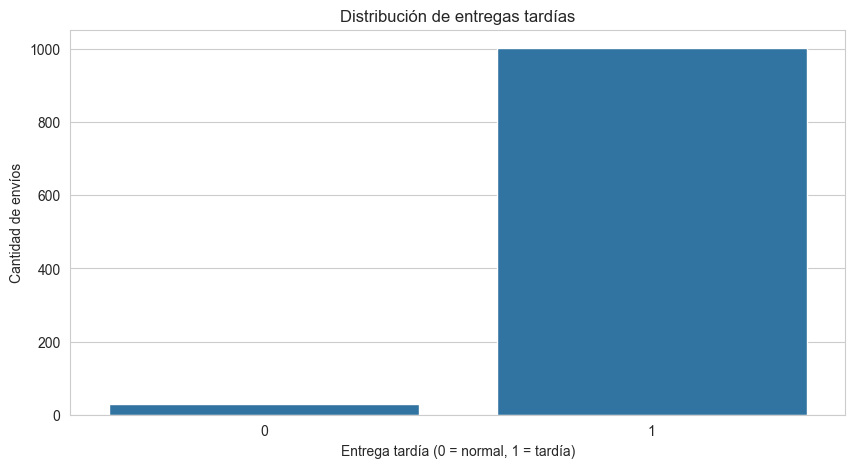

In [9]:

sns.countplot(data=df, x="entrega_tardia")

plt.title("Distribución de entregas tardías")
plt.xlabel("Entrega tardía (0 = normal, 1 = tardía)")
plt.ylabel("Cantidad de envíos")

plt.show()



### Análisis

La variable `entrega_tardia` permite transformar el problema logístico en un problema de clasificación.  
Su distribución es relevante porque permite observar si existe desbalance entre entregas normales y tardías, aspecto que posteriormente puede influir en la selección de métricas y modelos.



## 3.7 Distribución de días de entrega


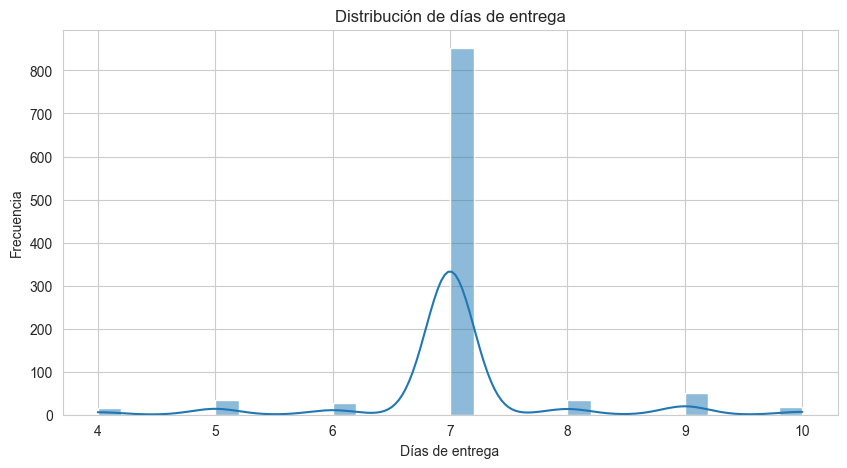

In [10]:

sns.histplot(df["dias_entrega"], bins=30, kde=True)

plt.title("Distribución de días de entrega")
plt.xlabel("Días de entrega")
plt.ylabel("Frecuencia")

plt.show()



### Análisis

La variable `dias_entrega` representa una posible variable objetivo para modelos de regresión, ya que permite estimar numéricamente la duración de una entrega.



## 3.8 Correlación entre variables numéricas


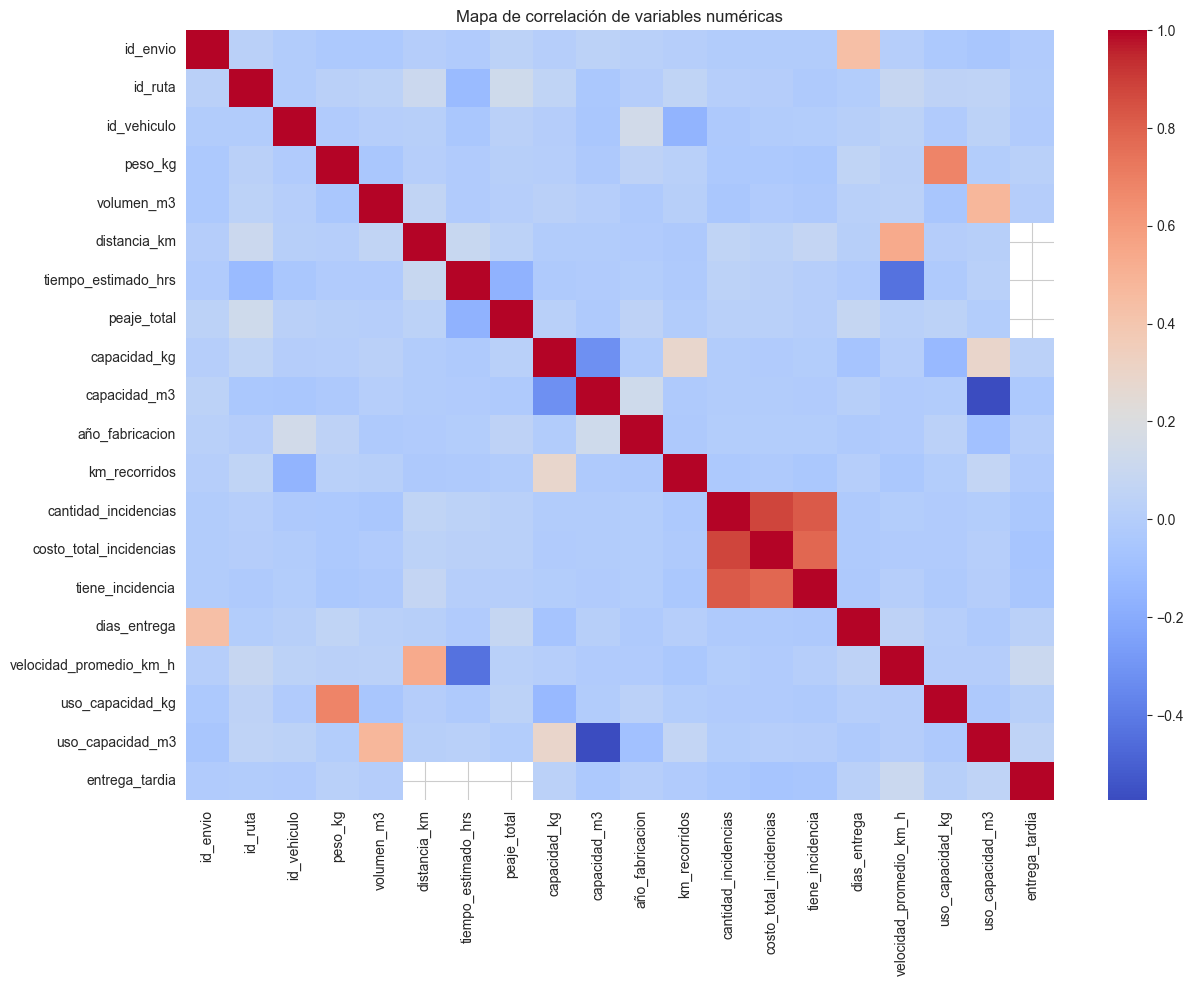

In [11]:

columnas_numericas = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))
sns.heatmap(columnas_numericas.corr(), cmap="coolwarm", annot=False)

plt.title("Mapa de correlación de variables numéricas")
plt.show()



### Análisis

El mapa de correlación permite identificar relaciones entre variables numéricas.  
Este paso ayuda a reconocer variables que podrían aportar información relevante para los modelos predictivos y también permite detectar posibles redundancias.



# 4. Análisis visual logístico

Esta sección profundiza en patrones relacionados con rutas, vehículos, incidencias, capacidad y retrasos.  
El objetivo es detectar relaciones útiles para la interpretación del negocio y para la futura selección de variables en los modelos.



## 4.1 Distancia recorrida según entrega tardía


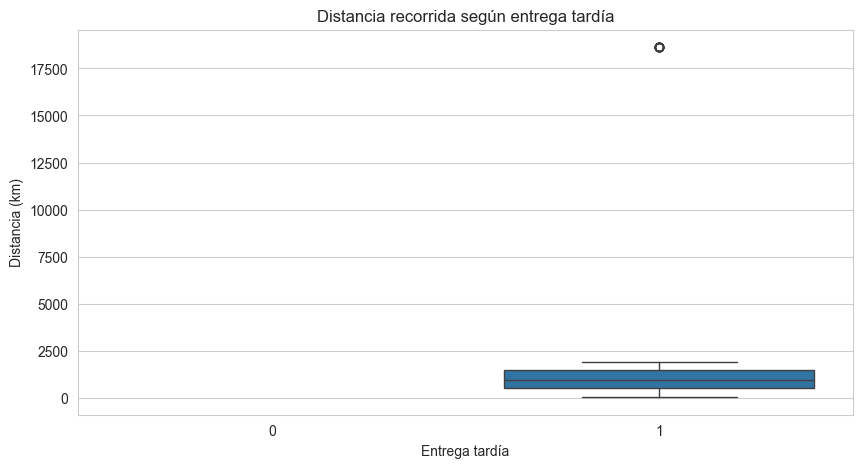

In [12]:

sns.boxplot(data=df, x="entrega_tardia", y="distancia_km")

plt.title("Distancia recorrida según entrega tardía")
plt.xlabel("Entrega tardía")
plt.ylabel("Distancia (km)")

plt.show()



### Análisis

Este gráfico permite observar si los envíos tardíos presentan una distribución distinta en la distancia recorrida.  
Si los envíos tardíos concentran distancias mayores o una mayor dispersión, la distancia podría ser una variable relevante para el modelado.



## 4.2 Peso del envío según entrega tardía


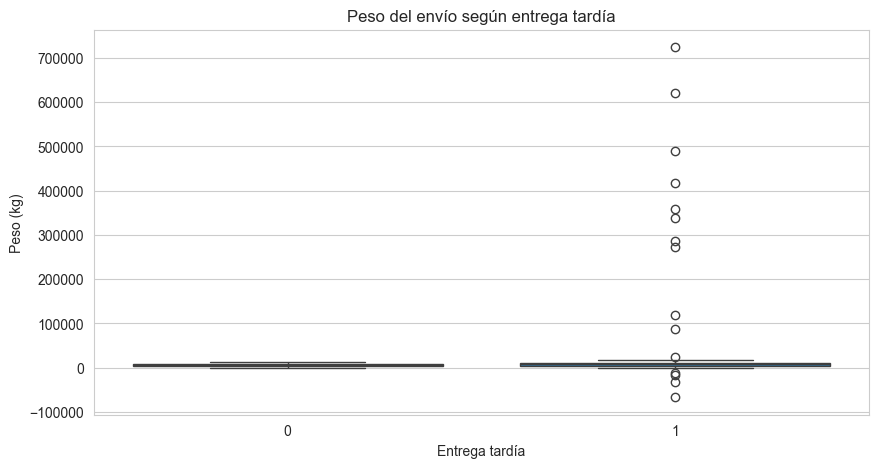

In [13]:

sns.boxplot(data=df, x="entrega_tardia", y="peso_kg")

plt.title("Peso del envío según entrega tardía")
plt.xlabel("Entrega tardía")
plt.ylabel("Peso (kg)")

plt.show()



### Análisis

El peso del envío puede afectar la planificación logística, especialmente cuando se relaciona con la capacidad disponible del vehículo.



## 4.3 Uso de capacidad del vehículo


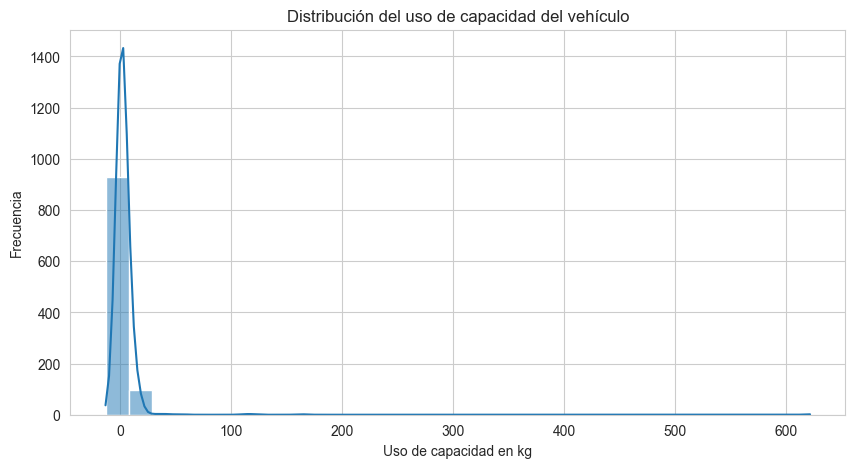

In [14]:

sns.histplot(df["uso_capacidad_kg"], bins=30, kde=True)

plt.title("Distribución del uso de capacidad del vehículo")
plt.xlabel("Uso de capacidad en kg")
plt.ylabel("Frecuencia")

plt.show()



### Análisis

El uso de capacidad permite evaluar qué tan aprovechados se encuentran los vehículos.  
Valores muy altos podrían indicar operaciones con mayor exigencia logística.



## 4.4 Uso de capacidad según entrega tardía


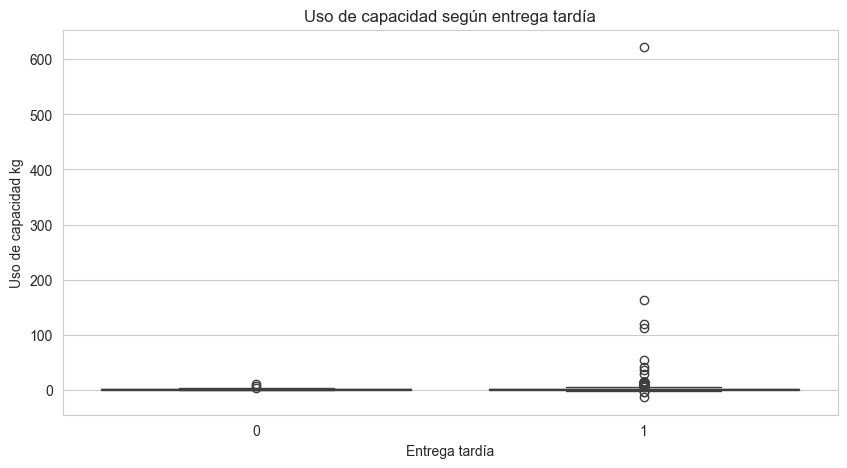

In [15]:

sns.boxplot(data=df, x="entrega_tardia", y="uso_capacidad_kg")

plt.title("Uso de capacidad según entrega tardía")
plt.xlabel("Entrega tardía")
plt.ylabel("Uso de capacidad kg")

plt.show()



### Análisis

Este gráfico permite revisar si los envíos tardíos tienen un comportamiento distinto en el nivel de uso de capacidad del vehículo.



## 4.5 Incidencias por tipo de vehículo


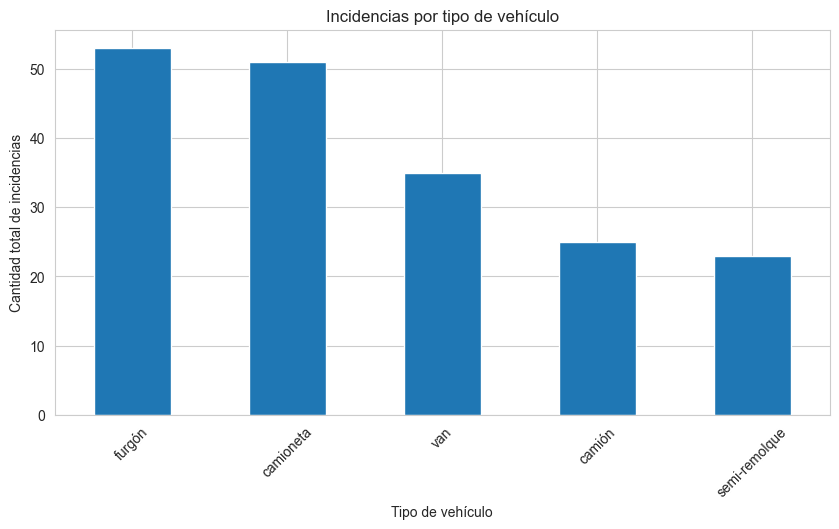

In [16]:

if "tipo" in df.columns:
    incidencias_tipo = (
        df.groupby("tipo")["cantidad_incidencias"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    incidencias_tipo.plot(kind="bar")

    plt.title("Incidencias por tipo de vehículo")
    plt.xlabel("Tipo de vehículo")
    plt.ylabel("Cantidad total de incidencias")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("La columna 'tipo' no está disponible en el dataset.")



### Análisis

El análisis por tipo de vehículo permite identificar si ciertos vehículos concentran más incidencias, lo que podría asociarse a mantenimiento, capacidad o uso operativo.



## 4.6 Rutas con más entregas tardías


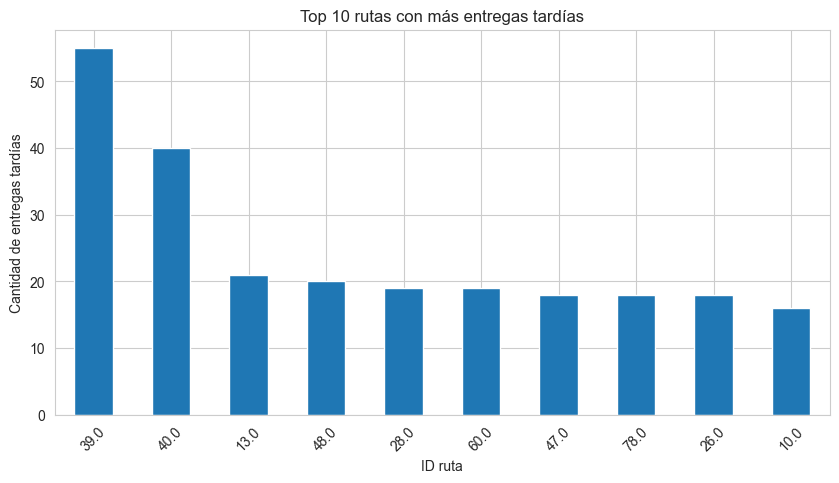

In [17]:

rutas_tardias = (
    df.groupby("id_ruta")["entrega_tardia"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

rutas_tardias.plot(kind="bar")

plt.title("Top 10 rutas con más entregas tardías")
plt.xlabel("ID ruta")
plt.ylabel("Cantidad de entregas tardías")
plt.xticks(rotation=45)

plt.show()



### Análisis

Este gráfico permite identificar rutas con mayor concentración de retrasos.  
Estas rutas podrían ser candidatas para revisión operacional o mejora en la planificación.



## 4.7 Costo total de incidencias


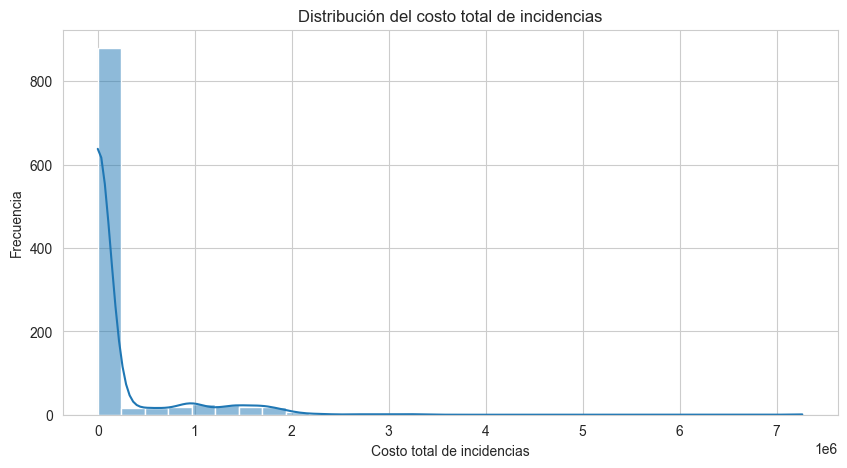

In [18]:

sns.histplot(df["costo_total_incidencias"], bins=30, kde=True)

plt.title("Distribución del costo total de incidencias")
plt.xlabel("Costo total de incidencias")
plt.ylabel("Frecuencia")

plt.show()



### Análisis

El costo total de incidencias permite identificar el impacto económico asociado a problemas durante el proceso logístico.



## 4.8 Velocidad promedio según entrega tardía


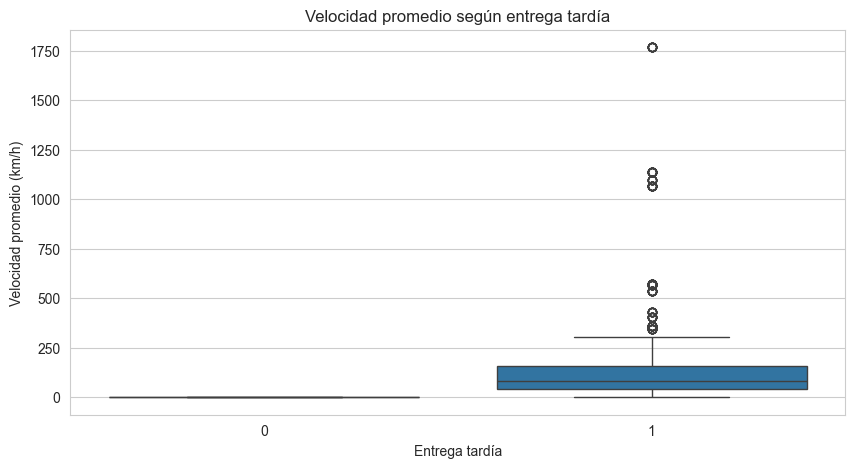

In [19]:

sns.boxplot(data=df, x="entrega_tardia", y="velocidad_promedio_km_h")

plt.title("Velocidad promedio según entrega tardía")
plt.xlabel("Entrega tardía")
plt.ylabel("Velocidad promedio (km/h)")

plt.show()



### Análisis

La velocidad promedio es una variable derivada que puede entregar información relevante sobre la eficiencia operacional de una ruta.



# 5. Enfoque del problema predictivo

En esta sección se define el enfoque de Machine Learning que se utilizará en los siguientes notebooks.  
Las instrucciones de la Evaluación 2 solicitan implementar modelos supervisados y no supervisados, evaluarlos, compararlos y justificar las decisiones técnicas. No se indica una variable objetivo específica, por lo que se debe proponer un enfoque coherente con el problema logístico.



## 5.1 ¿Por qué predecir entregas tardías?

La variable `entrega_tardia` representa un problema real para una empresa logística.  
Predecir si un envío podría llegar tarde permite tomar decisiones antes de que el problema ocurra.

Por ejemplo:

- Ajustar rutas.
- Reasignar vehículos.
- Informar anticipadamente al cliente.
- Priorizar envíos críticos.
- Reducir costos asociados a incumplimientos.

Por esta razón, `entrega_tardia` se propone como variable objetivo para un modelo de clasificación.


In [20]:

df["entrega_tardia"].value_counts()



entrega_tardia
1    1002
0      28
Name: count, dtype: int64


## 5.2 ¿Por qué predecir días de entrega?

La variable `dias_entrega` permite estimar numéricamente cuánto podría tardar una entrega.

Este enfoque responde a una pregunta distinta:

> ¿Cuántos días podría demorar un envío?

Por esta razón, `dias_entrega` se propone como variable objetivo para un modelo de regresión.


In [21]:

df["dias_entrega"].describe()



count   1,030.00
mean        7.04
std         0.82
min         4.00
25%         7.00
50%         7.00
75%         7.00
max        10.00
Name: dias_entrega, dtype: float64


## 5.3 Posibles variables predictoras

Las siguientes variables podrían utilizarse como entradas para los modelos, ya que representan información logística relevante:

- `distancia_km`
- `tiempo_estimado_hrs`
- `peso_kg`
- `volumen_m3`
- `capacidad_kg`
- `capacidad_m3`
- `cantidad_incidencias`
- `tiene_incidencia`
- `uso_capacidad_kg`
- `velocidad_promedio_km_h`

Estas variables serán revisadas con mayor detalle en los notebooks de modelado.


In [22]:

posibles_predictoras = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "cantidad_incidencias",
    "tiene_incidencia",
    "uso_capacidad_kg",
    "velocidad_promedio_km_h"
]

df[posibles_predictoras].head()


,distancia_km,tiempo_estimado_hrs,peso_kg,volumen_m3,capacidad_kg,capacidad_m3,cantidad_incidencias,tiene_incidencia,uso_capacidad_kg,velocidad_promedio_km_h
0,919.30,16.70,"12,675.80",28.48,"10,000.00",20.50,0.00,0.00,1.27,55.05
1,679.60,18.40,13.60,24.93,"1,000.00",22.10,0.00,0.00,0.01,36.93
2,468.40,5.20,"2,536.00",50.55,"20,000.00",38.90,0.00,0.00,0.13,90.08
3,"1,642.40",18.90,466.00,13.88,"1,000.00",25.30,1.00,1.00,0.47,86.90
4,"1,556.60",17.90,"4,928.90",0.44,"5,000.00",49.10,0.00,0.00,0.99,86.96



## 5.4 Precaución: fuga de información

Para entrenar modelos predictivos es importante evitar variables que entreguen información que solo estaría disponible después de finalizar el envío.

Por ejemplo, si se quiere predecir `entrega_tardia`, se debe tener cuidado con variables como:

- `fecha_entrega`
- `dias_entrega`

Estas variables pueden generar **data leakage**, es decir, fuga de información.  
En los siguientes notebooks se seleccionarán variables considerando qué información estaría disponible antes o durante la planificación logística.



# 6. Conclusiones del análisis exploratorio

A partir del análisis exploratorio se identifican varios elementos relevantes para continuar con la Evaluación 2:

- El dataset final generado por Kedro está listo para análisis y modelado.
- La variable `entrega_tardia` permite plantear un problema de clasificación.
- La variable `dias_entrega` permite plantear un problema de regresión.
- Las variables logísticas derivadas, como `uso_capacidad_kg`, `velocidad_promedio_km_h` y `cantidad_incidencias`, aportan información útil para explicar el comportamiento de los envíos.
- Existen patrones asociados a rutas, vehículos, distancia e incidencias que justifican avanzar hacia modelos predictivos.

Con este notebook se cumple la etapa de análisis exploratorio, visualización y detección de patrones solicitada antes de implementar los modelos supervisados.
